In [1]:
# 1.IMPORTING DEPENDENCIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [11]:
# 2.LOADING UNPROCESSED DATASET
file_path = r"C:\Users\anmol\Downloads\accident_pothole_dataset_800.csv"
df = pd.read_csv(file_path)
df.head(100)

,pothole_depth_cm,pothole_width_cm,pothole_area_cm2,pothole_severity,pothole_count_in_10m,road_type,road_condition,lane_count,speed_limit,traffic_density,...,tyre_condition,weather,visibility_m,light_condition,latitude,longitude,road_severity,accident_chance,maintain_speed_two_wheeler,maintain_speed_four_wheeler
0,7,48,684,Low,1,City,Dry,2,40,Low,...,Average,Cloudy,230,Daylight,13.782759,74.002603,Safe,0.20,60,80
1,20,47,498,High,1,City,Muddy,3,80,High,...,Worn out,Sunny,114,Daylight,9.621976,94.627602,Moderate,0.58,40,55
2,15,43,916,High,1,City,Gravel,4,60,Low,...,Good,Rainy,242,Daylight,16.788590,91.640227,Safe,0.19,60,80
3,11,47,1467,High,2,City,Wet,2,100,High,...,Average,Sunny,28,Night,11.879566,96.386824,Moderate,0.53,40,55
4,8,59,1063,High,4,City,Gravel,2,60,Medium,...,Average,Rainy,72,Streetlights,27.168193,93.527301,Moderate,0.46,40,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,7,37,1083,High,4,Rural,Dry,4,80,Low,...,Average,Foggy,464,Daylight,18.761099,82.389102,Moderate,0.44,40,55
96,9,32,1247,High,4,City,Muddy,4,60,High,...,Worn out,Rainy,37,Daylight,12.594121,91.916972,Moderate,0.44,40,55
97,24,23,1074,High,5,City,Muddy,1,100,Low,...,Worn out,Sunny,89,Streetlights,14.877454,79.662535,Dangerous,0.88,25,35
98,1,33,137,High,4,Rural,Wet,3,50,Low,...,Average,Sunny,357,Night,15.107647,70.969439,Moderate,0.58,40,55


In [13]:
# 3.IDENTIFYING SHAPE OF THE DATASET
df.shape

(800, 24)

In [15]:
# 4.IDENTIFYING COLUMNS
df.columns

Index(['pothole_depth_cm', 'pothole_width_cm', 'pothole_area_cm2',
       'pothole_severity', 'pothole_count_in_10m', 'road_type',
       'road_condition', 'lane_count', 'speed_limit', 'traffic_density',
       'vehicle_speed', 'brake_applied', 'sudden_steering_change',
       'vehicle_type', 'tyre_condition', 'weather', 'visibility_m',
       'light_condition', 'latitude', 'longitude', 'road_severity',
       'accident_chance', 'maintain_speed_two_wheeler',
       'maintain_speed_four_wheeler'],
      dtype='object')

In [17]:
# 5.DATA CLEANINg
#getting summary of null values for all columns of all rows 
df.isnull().sum()

pothole_depth_cm               0
pothole_width_cm               0
pothole_area_cm2               0
pothole_severity               0
pothole_count_in_10m           0
road_type                      0
road_condition                 0
lane_count                     0
speed_limit                    0
traffic_density                0
vehicle_speed                  0
brake_applied                  0
sudden_steering_change         0
vehicle_type                   0
tyre_condition                 0
weather                        0
visibility_m                   0
light_condition                0
latitude                       0
longitude                      0
road_severity                  0
accident_chance                0
maintain_speed_two_wheeler     0
maintain_speed_four_wheeler    0
dtype: int64

In [19]:
#Replace missing values if exists
df = df.replace("?", np.nan)

In [21]:
df.head(100)

,pothole_depth_cm,pothole_width_cm,pothole_area_cm2,pothole_severity,pothole_count_in_10m,road_type,road_condition,lane_count,speed_limit,traffic_density,...,tyre_condition,weather,visibility_m,light_condition,latitude,longitude,road_severity,accident_chance,maintain_speed_two_wheeler,maintain_speed_four_wheeler
0,7,48,684,Low,1,City,Dry,2,40,Low,...,Average,Cloudy,230,Daylight,13.782759,74.002603,Safe,0.20,60,80
1,20,47,498,High,1,City,Muddy,3,80,High,...,Worn out,Sunny,114,Daylight,9.621976,94.627602,Moderate,0.58,40,55
2,15,43,916,High,1,City,Gravel,4,60,Low,...,Good,Rainy,242,Daylight,16.788590,91.640227,Safe,0.19,60,80
3,11,47,1467,High,2,City,Wet,2,100,High,...,Average,Sunny,28,Night,11.879566,96.386824,Moderate,0.53,40,55
4,8,59,1063,High,4,City,Gravel,2,60,Medium,...,Average,Rainy,72,Streetlights,27.168193,93.527301,Moderate,0.46,40,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,7,37,1083,High,4,Rural,Dry,4,80,Low,...,Average,Foggy,464,Daylight,18.761099,82.389102,Moderate,0.44,40,55
96,9,32,1247,High,4,City,Muddy,4,60,High,...,Worn out,Rainy,37,Daylight,12.594121,91.916972,Moderate,0.44,40,55
97,24,23,1074,High,5,City,Muddy,1,100,Low,...,Worn out,Sunny,89,Streetlights,14.877454,79.662535,Dangerous,0.88,25,35
98,1,33,137,High,4,Rural,Wet,3,50,Low,...,Average,Sunny,357,Night,15.107647,70.969439,Moderate,0.58,40,55


In [23]:
#Getting datatypes summary
df.dtypes

pothole_depth_cm                 int64
pothole_width_cm                 int64
pothole_area_cm2                 int64
pothole_severity                object
pothole_count_in_10m             int64
road_type                       object
road_condition                  object
lane_count                       int64
speed_limit                      int64
traffic_density                 object
vehicle_speed                    int64
brake_applied                    int64
sudden_steering_change           int64
vehicle_type                    object
tyre_condition                  object
weather                         object
visibility_m                     int64
light_condition                 object
latitude                       float64
longitude                      float64
road_severity                   object
accident_chance                float64
maintain_speed_two_wheeler       int64
maintain_speed_four_wheeler      int64
dtype: object

In [25]:
#Removing Duplicates if exist
df.duplicated().sum()
df.drop_duplicates()

,pothole_depth_cm,pothole_width_cm,pothole_area_cm2,pothole_severity,pothole_count_in_10m,road_type,road_condition,lane_count,speed_limit,traffic_density,...,tyre_condition,weather,visibility_m,light_condition,latitude,longitude,road_severity,accident_chance,maintain_speed_two_wheeler,maintain_speed_four_wheeler
0,7,48,684,Low,1,City,Dry,2,40,Low,...,Average,Cloudy,230,Daylight,13.782759,74.002603,Safe,0.20,60,80
1,20,47,498,High,1,City,Muddy,3,80,High,...,Worn out,Sunny,114,Daylight,9.621976,94.627602,Moderate,0.58,40,55
2,15,43,916,High,1,City,Gravel,4,60,Low,...,Good,Rainy,242,Daylight,16.788590,91.640227,Safe,0.19,60,80
3,11,47,1467,High,2,City,Wet,2,100,High,...,Average,Sunny,28,Night,11.879566,96.386824,Moderate,0.53,40,55
4,8,59,1063,High,4,City,Gravel,2,60,Medium,...,Average,Rainy,72,Streetlights,27.168193,93.527301,Moderate,0.46,40,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,5,46,597,Low,0,Rural,Wet,4,50,Low,...,Average,Foggy,216,Streetlights,21.828589,76.994269,Safe,0.22,60,80
796,21,34,463,Low,5,Rural,Wet,2,80,Medium,...,Worn out,Foggy,199,Night,17.723837,81.088765,Dangerous,0.84,25,35
797,14,57,990,Medium,0,Highway,Muddy,4,40,Low,...,Worn out,Rainy,361,Night,20.555954,79.141631,Moderate,0.57,40,55
798,2,10,526,Medium,5,Highway,Gravel,2,60,Low,...,Good,Cloudy,152,Streetlights,26.627192,80.537683,Moderate,0.54,40,55


In [27]:
#gettinf summary of duplicates again
df.duplicated().sum()

0

In [51]:
#Outlier detection
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("OUTLIER REMOVAL STARTD")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df.shape[0]
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = df.shape[0]

    print(f"{col} → Removed {before - after} outliers")

print("Outlier removal complete")

OUTLIER REMOVAL STARTD
pothole_depth_cm → Removed 0 outliers
pothole_width_cm → Removed 0 outliers
pothole_area_cm2 → Removed 0 outliers
pothole_severity → Removed 0 outliers
pothole_count_in_10m → Removed 0 outliers
road_type → Removed 0 outliers
road_condition → Removed 0 outliers
lane_count → Removed 0 outliers
speed_limit → Removed 0 outliers
traffic_density → Removed 0 outliers
vehicle_speed → Removed 0 outliers
brake_applied → Removed 0 outliers
sudden_steering_change → Removed 0 outliers
vehicle_type → Removed 0 outliers
tyre_condition → Removed 0 outliers
weather → Removed 0 outliers
visibility_m → Removed 0 outliers
light_condition → Removed 0 outliers
latitude → Removed 0 outliers
longitude → Removed 0 outliers
accident_chance → Removed 0 outliers
maintain_speed_two_wheeler → Removed 0 outliers
maintain_speed_four_wheeler → Removed 0 outliers
pothole_area_speed_ratio → Removed 44 outliers
combined_danger_score → Removed 0 outliers
speed_over_limit → Removed 0 outliers
Outlier

In [53]:
#Feature Engineering
print("ADDING ADDITIONAL FEATURES")

# Convert to classification target
df["accident_risk"] = (df["accident_chance"] > 0.5).astype(int)

# Ratio of pothole area to vehicle speed
df["pothole_area_speed_ratio"] = df["pothole_area_cm2"] / (df["vehicle_speed"] + 1)

# Danger score combining depth & count
df["combined_danger_score"] = (
    df["pothole_depth_cm"] * 0.6 +
    df["pothole_count_in_10m"] * 2 +
    df["vehicle_speed"] * 0.2
)

# Whether speed exceeds limit
df["speed_over_limit"] = (df["vehicle_speed"] > df["speed_limit"]).astype(int)

print("Feature engineering completed.\n")

ADDING ADDITIONAL FEATURES
Feature engineering completed.



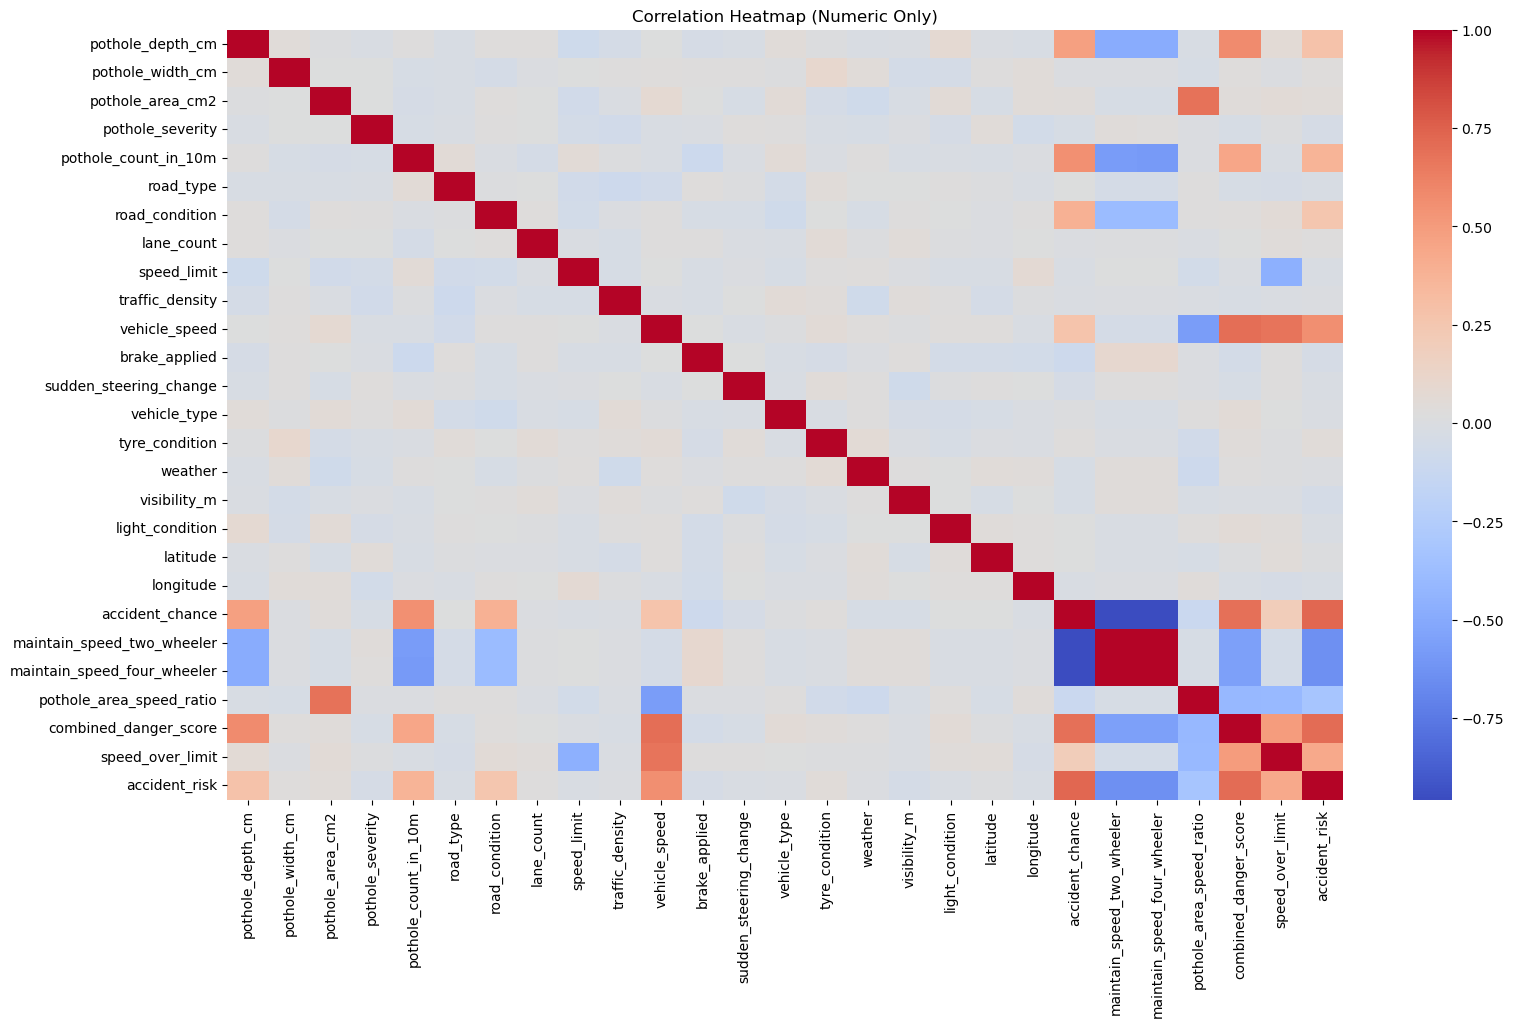

In [55]:
#Correlation Matrix
plt.figure(figsize=(18, 10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Only)")
plt.show()

In [57]:
#Encoding categorical variables
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nCategorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

targets = ["accident_chance", "road_severity"]
categorical_cols = [col for col in categorical_cols if col not in targets]

label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("Label encoding completed.")



Categorical Columns: ['road_severity']
Numerical Columns: ['pothole_depth_cm', 'pothole_width_cm', 'pothole_area_cm2', 'pothole_severity', 'pothole_count_in_10m', 'road_type', 'road_condition', 'lane_count', 'speed_limit', 'traffic_density', 'vehicle_speed', 'brake_applied', 'sudden_steering_change', 'vehicle_type', 'tyre_condition', 'weather', 'visibility_m', 'light_condition', 'latitude', 'longitude', 'accident_chance', 'maintain_speed_two_wheeler', 'maintain_speed_four_wheeler', 'pothole_area_speed_ratio', 'combined_danger_score', 'speed_over_limit', 'accident_risk']
Label encoding completed.


In [59]:
# Train test split
print(" TRAIN-TEST SPLIT ")

X = df.drop(["accident_chance", "road_severity", "accident_risk"], axis=1)
y = df["accident_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

 TRAIN-TEST SPLIT 
Training Set: (604, 25)
Testing Set: (152, 25)


In [61]:
# Saving processed data
X_train.to_csv("processed_X_train.csv", index=False)
X_test.to_csv("processed_X_test.csv", index=False)
y_train.to_csv("processed_y_train.csv", index=False)
y_test.to_csv("processed_y_test.csv", index=False)

print("\n===== PREPROCESSING COMPLETE =====")
print("Processed datasets saved successfully.")


===== PREPROCESSING COMPLETE =====
Processed datasets saved successfully.


In [65]:
# ==============================
# CREATE CLASSIFICATION TARGET
# ==============================

print("Preparing final training dataset...")

# Convert continuous to binary (0 or 1)
df["accident_risk"] = (df["accident_chance"] > 0.5).astype(int)

print("Unique target values:", df["accident_risk"].unique())


# ==============================
# DEFINE FEATURES & TARGET
# ==============================

X = df.drop(["accident_chance", "road_severity", "accident_risk"], axis=1)
y = df["accident_risk"]


# ==============================
# TRAIN-TEST SPLIT
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)


# ==============================
# TRAIN RANDOM FOREST CLASSIFIER
# ==============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("\nTraining Random Forest Classifier...")

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)


# ==============================
# EVALUATION
# ==============================

y_pred = model.predict(X_test)

print("\nModel Evaluation Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# ==============================
# SAVE MODEL
# ==============================

import joblib

joblib.dump(model, "accident_prediction_model.pkl")

print("\nModel saved successfully as accident_prediction_model.pkl")

Preparing final training dataset...
Unique target values: [0 1]
Training Set: (604, 25)
Testing Set: (152, 25)

Training Random Forest Classifier...

Model Evaluation Results
Accuracy: 0.9803

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        78
           1       1.00      0.96      0.98        74

    accuracy                           0.98       152
   macro avg       0.98      0.98      0.98       152
weighted avg       0.98      0.98      0.98       152


Model saved successfully as accident_prediction_model.pkl


In [67]:
import joblib
import pandas as pd

# Load saved model
model = joblib.load("accident_prediction_model.pkl")

print("Model loaded successfully")


Model loaded successfully


In [71]:
import joblib
import pandas as pd

# Load model
model = joblib.load("accident_prediction_model.pkl")

def simplified_prediction(depth, count, traffic_density, weather):
    
    # Default values
    speed_limit = 60
    vehicle_speed = 50
    lane_count = 2
    visibility = 150
    
    traffic_map = {"Low": 0, "Medium": 1, "High": 2}
    weather_map = {"Sunny": 0, "Cloudy": 1, "Rainy": 2, "Foggy": 3}
    
    user_data = {
        "pothole_depth_cm": depth,
        "pothole_width_cm": 40,
        "pothole_area_cm2": depth * 40,
        "pothole_severity": 2,
        "pothole_count_in_10m": count,
        "road_type": 1,
        "road_condition": 2,
        "lane_count": lane_count,
        "speed_limit": speed_limit,
        "traffic_density": traffic_map[traffic_density],
        "vehicle_speed": vehicle_speed,
        "brake_applied": 0,
        "sudden_steering_change": 0,
        "vehicle_type": 1,
        "tyre_condition": 1,
        "weather": weather_map[weather],
        "visibility_m": visibility,
        "light_condition": 0,
        "latitude": 18.5,
        "longitude": 73.8,
        "maintain_speed_two_wheeler": 40,
        "maintain_speed_four_wheeler": 55,
        "pothole_area_speed_ratio": (depth * 40) / (vehicle_speed + 1),
        "combined_danger_score": (depth * 0.6 + count * 2 + vehicle_speed * 0.2),
        "speed_over_limit": 0
    }
    
    input_df = pd.DataFrame([user_data])
    
    accident_prob = model.predict(input_df)[0]
    accident_percentage = accident_prob * 100
    
    if accident_percentage > 75:
        safe_speed = speed_limit * 0.5
    elif accident_percentage > 50:
        safe_speed = speed_limit * 0.7
    else:
        safe_speed = speed_limit * 0.9
    
    return round(accident_percentage, 2), round(safe_speed, 2)


In [73]:
percentage, safe_speed = simplified_prediction(
    depth=20,
    count=3,
    traffic_density="High",
    weather="Rainy"
)

print("Accident Risk:", percentage, "%")
print("Safe Speed:", safe_speed, "km/h")


Accident Risk: 0 %
Safe Speed: 54.0 km/h


In [49]:
!pip install streamlit
